# Homework part I

The first problem set contains basic tasks in PyTorch.

__Note:__ Instead of doing this part of homework, you can prove your skills otherwise:
* A commit to PyTorch or PyTorch-based repos will do;
* Fully implemented seminar assignment in tensorflow or theano will do;
* Your own project in PyTorch that is developed to a state in which a normal human can understand and appreciate what it does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
print(torch.__version__)
from IPython.display import display, clear_output
import time

2.11.0


### Task I - tensormancy

![img](https://media.giphy.com/media/3o751UMCYtSrRAFRFC/giphy.gif)

When dealing with more complex stuff like neural network, it's best if you use tensors the way samurai uses his sword. 


__1.1 The Cannabola__
[(_disclaimer_)](https://gist.githubusercontent.com/justheuristic/e2c1fa28ca02670cabc42cacf3902796/raw/fd3d935cef63a01b85ed2790b5c11c370245cbd7/stddisclaimer.h)

Let's write another function, this time in polar coordinates:
$$\rho(\theta) = (1 + 0.9 \cdot cos (8 \cdot \theta) ) \cdot (1 + 0.1 \cdot cos(24 \cdot \theta)) \cdot (0.9 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (1 + sin(\theta))$$


Then convert it into cartesian coordinates ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html)) and plot the results.

Use torch tensors only: no lists, loops, numpy arrays, etc.

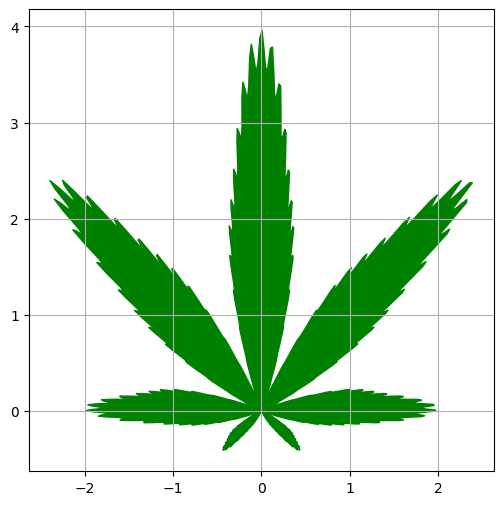

In [2]:
theta = torch.linspace(-np.pi, np.pi, steps=1000)

# compute rho(theta) as per formula above
rho = ((1 + 0.9 * torch.cos(8 * theta))
       * (1 + 0.1 * torch.cos(24 * theta))
       * (0.9 + 0.05 * torch.cos(200 * theta))
       * (1 + torch.sin(theta)))

# Now convert polar (rho, theta) pairs into cartesian (x,y) to plot them.
x = rho * torch.cos(theta)
y = rho * torch.sin(theta)


plt.figure(figsize=[6, 6])
plt.fill(x.numpy(), y.numpy(), color='green')
plt.grid()

### Task II: The Game of Life

Now it's time for you to make something more challenging. We'll implement Conway's [Game of Life](http://web.stanford.edu/~cdebs/GameOfLife/) in _pure PyTorch_.

While this is still a toy task, implementing game of life this way has one cool benefit: __you'll be able to run it on GPU!__ Indeed, what could be a better use of your GPU than simulating Game of Life on 1M/1M grids?

![img](https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif)

If you've skipped the URL above out of sloth, here's the Game of Life:
* You have a 2D grid of cells, where each cell is "alive"(1) or "dead"(0)
* Any living cell that has 2 or 3 neighbors survives, else it dies [0,1 or 4+ neighbors]
* Any cell with exactly 3 neighbors becomes alive (if it was dead)

For this task, you are given a reference NumPy implementation that you must convert to PyTorch.
_[NumPy code inspired by: https://github.com/rougier/numpy-100]_


__Note:__ You can find convolution in `torch.nn.functional.conv2d(Z,filters)`. Note that it has a different input format.

__Note 2:__ From the mathematical standpoint, PyTorch convolution is actually cross-correlation. Those two are very similar operations. More info: [video tutorial](https://www.youtube.com/watch?v=C3EEy8adxvc), [scipy functions review](http://programmerz.ru/questions/26903/2d-convolution-in-python-similar-to-matlabs-conv2-question), [stack overflow source](https://stackoverflow.com/questions/31139977/comparing-matlabs-conv2-with-scipys-convolve2d).

In [3]:
from scipy.signal import correlate2d

def np_update(Z):
    # Count neighbours with convolution
    filters = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]])

    N = correlate2d(Z, filters, mode='same')

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z

In [4]:
def torch_update(Z):
    """
    Implement an update function that does to Z exactly the same as np_update.
    :param Z: torch.FloatTensor of shape [height,width] containing 0s(dead) an 1s(alive)
    :returns: torch.FloatTensor Z after updates.
    
    You can opt to create new tensor or change Z inplace.
    """
    
    # count the neighbours of every cell
    filters = torch.tensor([[1, 1, 1],
                            [1, 0, 1],
                            [1, 1, 1]], dtype=Z.dtype, device=Z.device)
    filters = filters.view(1, 1, 3, 3)
    neighbours = F.conv2d(Z[None, None], filters, padding=1)[0, 0]

    # apply the rules of the game
    birth = (neighbours == 3) & (Z == 0)
    survive = ((neighbours == 2) | (neighbours == 3)) & (Z == 1)
    Z = (birth | survive).to(Z.dtype)
    
    return Z


In [5]:
# initial frame
Z_numpy = np.random.choice([0, 1], p=(0.5, 0.5), size=(100, 100))
Z = torch.from_numpy(Z_numpy).type(torch.FloatTensor)

# your debug polygon :)
Z_new = torch_update(Z.clone())

# tests
Z_reference = np_update(Z_numpy.copy())
assert np.all(Z_new.numpy() == Z_reference), \
    "your PyTorch implementation doesn't match np_update. Look into Z and np_update(ZZ) to investigate."
print("Well done!")

Well done!


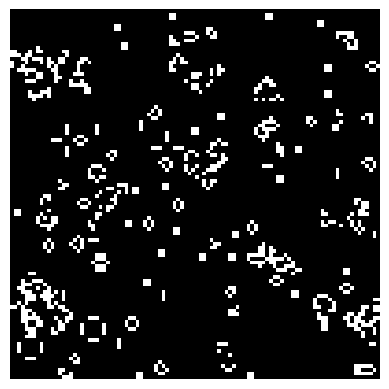

In [6]:
%matplotlib inline
plt.close('all')

# initialize game field
Z = np.random.choice([0, 1], size=(100, 100))
Z = torch.from_numpy(Z).type(torch.FloatTensor)

# replaced the plotting method so the animation works correctly in VS Code
fig, ax = plt.subplots()
image = ax.imshow(Z.numpy(), cmap='gray')
ax.axis('off')

for _ in range(100):
    # update
    Z = torch_update(Z)

    # update the same figure
    image.set_data(Z.numpy())
    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

plt.close(fig)

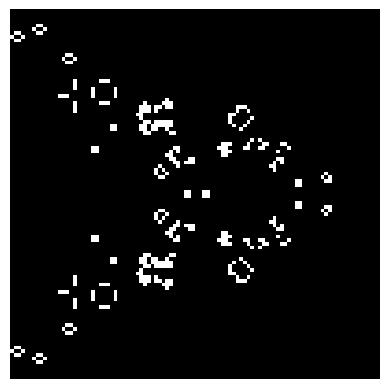

In [7]:
# Some fun setups for your amusement

# parallel stripes
Z = np.arange(100) % 2 + np.zeros([100, 100])

# with a small imperfection
Z[48:52, 50] = 1
Z = torch.from_numpy(Z).type(torch.FloatTensor)

# replaced the plotting method so the animation works correctly in VS Code
plt.close('all')

fig, ax = plt.subplots()
image = ax.imshow(Z.numpy(), cmap='gray')
ax.axis('off')

for _ in range(100):
    Z = torch_update(Z)

    image.set_data(Z.numpy())
    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

plt.close(fig)

More fun with Game of Life: [video](https://www.youtube.com/watch?v=C2vgICfQawE) and/or [Jupyter Notebook](https://nbviewer.jupyter.org/url/norvig.com/ipython/Life.ipynb)

### Task III: Going deeper
<img src="https://www.meme-arsenal.com/memes/00ad90d844e491aaeb6892515c716710.jpg" width=360>

Your third trial is to build your first neural network [almost] from scratch and pure PyTorch.

This time you will solve yet another digit recognition problem, but at a greater scale

* 10 different letters
* 20k samples

We want you to build a network that reaches at least 80% accuracy and has at least 2 linear layers in it. Naturally, it should be nonlinear to beat logistic regression.


With 10 classes you will need to use __Softmax__ at the top instead of sigmoid and train using __categorical crossentropy__ .  Write your own loss or use `torch.nn.functional.nll_loss`. Just make sure you understand what it accepts as input.

Note that you are not required to build 152-layer monsters here. A 2-layer (one hidden, one output) neural network should already give you an edge over logistic regression.


__[bonus kudos]__
If you've already beaten logistic regression with a two-layer net, but enthusiasm still ain't gone, you can try improving the test accuracy even further! It should be possible to reach 90% without convnets.

__SPOILERS!__
At the end of the notebook you will find a few tips and frequent errors.
If you feel confident enough, just start coding right away and get there ~~if~~ once you need to untangle yourself.

In [8]:
from notmnist import load_notmnist
X_train, y_train, X_test, y_test = load_notmnist(letters='ABCDEFGHIJ')
X_train, X_test = X_train.reshape([-1, 784]), X_test.reshape([-1, 784])

Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done


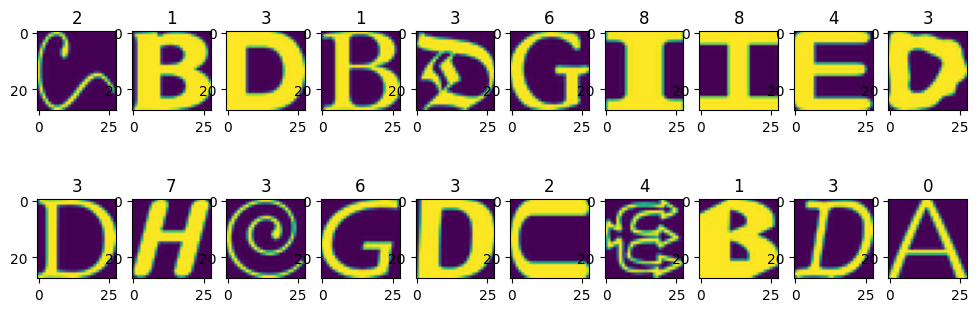

In [9]:
%matplotlib inline
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[i].reshape([28, 28]))
    plt.title(str(y_train[i]))

In [10]:
# tensors for training
torch.manual_seed(42)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
batch_size = 256

# binary logistic regression for A against the other letters
binary_train = (y_train_tensor == 0).float()
binary_test = (y_test_tensor == 0).float()
binary_model = nn.Linear(784, 1)
binary_optimizer = torch.optim.Adam(binary_model.parameters(), lr=1e-3)

for epoch in range(5):
    permutation = torch.randperm(len(X_train_tensor))
    epoch_loss = 0.0

    for start in range(0, len(X_train_tensor), batch_size):
        indices = permutation[start:start + batch_size]
        logits = binary_model(X_train_tensor[indices]).squeeze(1)
        loss = F.binary_cross_entropy_with_logits(logits, binary_train[indices])

        binary_optimizer.zero_grad()
        loss.backward()
        binary_optimizer.step()
        epoch_loss += loss.item() * len(indices)

    print(f'binary epoch {epoch + 1:02d}: loss = '
          f'{epoch_loss / len(X_train_tensor):.4f}')

binary_model.eval()
with torch.no_grad():
    binary_probabilities = torch.sigmoid(binary_model(X_test_tensor).squeeze(1))
    binary_predictions = (binary_probabilities >= 0.5).float()
    binary_accuracy = (binary_predictions == binary_test).float().mean().item()

print(f'A vs rest test accuracy = {binary_accuracy:.4f}')

binary epoch 01: loss = 0.2587
binary epoch 02: loss = 0.1678
binary epoch 03: loss = 0.1539
binary epoch 04: loss = 0.1449
binary epoch 05: loss = 0.1383
A vs rest test accuracy = 0.9481


In [11]:
# trainin and testing a model for all ten letters
def train_multiclass(model, num_epochs, model_name):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        permutation = torch.randperm(len(X_train_tensor))
        epoch_loss = 0.0
        correct = 0

        for start in range(0, len(X_train_tensor), batch_size):
            indices = permutation[start:start + batch_size]
            x_batch = X_train_tensor[indices]
            y_batch = y_train_tensor[indices]

            logits = model(x_batch)
            loss = F.cross_entropy(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(indices)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()

        train_loss = epoch_loss / len(X_train_tensor)
        train_accuracy = correct / len(X_train_tensor)
        print(f'{model_name} epoch {epoch + 1:02d}: loss = {train_loss:.4f}, '
              f'train accuracy = {train_accuracy:.4f}')

    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_tensor).argmax(dim=1)
        test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

    return test_accuracy

# multiclass logistic regression
logistic_model = nn.Linear(784, 10)
logistic_accuracy = train_multiclass(logistic_model, 10, 'logistic')
print(f'logistic regression test accuracy = {logistic_accuracy:.4f}')

logistic epoch 01: loss = 0.8261, train accuracy = 0.7776
logistic epoch 02: loss = 0.4722, train accuracy = 0.8790
logistic epoch 03: loss = 0.4322, train accuracy = 0.8876
logistic epoch 04: loss = 0.4111, train accuracy = 0.8944
logistic epoch 05: loss = 0.3967, train accuracy = 0.8967
logistic epoch 06: loss = 0.3857, train accuracy = 0.9000
logistic epoch 07: loss = 0.3762, train accuracy = 0.9022
logistic epoch 08: loss = 0.3699, train accuracy = 0.9047
logistic epoch 09: loss = 0.3631, train accuracy = 0.9047
logistic epoch 10: loss = 0.3582, train accuracy = 0.9054
logistic regression test accuracy = 0.8870


In [12]:
# NN with one hidden layer
neural_network = nn.Sequential(nn.Linear(784, 128),
                               nn.ReLU(),
                               nn.Linear(128, 10))
neural_network_accuracy = train_multiclass(neural_network, 15, 'network')
print(f'neural network test accuracy = {neural_network_accuracy:.4f}\n')

# comparison of 2 multiclass models
print(f'logistic regression: {logistic_accuracy:.4f}')
print(f'neural network:      {neural_network_accuracy:.4f}')
assert neural_network_accuracy > logistic_accuracy
assert neural_network_accuracy >= 0.80

network epoch 01: loss = 0.6365, train accuracy = 0.8322
network epoch 02: loss = 0.3451, train accuracy = 0.9002
network epoch 03: loss = 0.2962, train accuracy = 0.9143
network epoch 04: loss = 0.2604, train accuracy = 0.9246
network epoch 05: loss = 0.2327, train accuracy = 0.9341
network epoch 06: loss = 0.2074, train accuracy = 0.9420
network epoch 07: loss = 0.1842, train accuracy = 0.9489
network epoch 08: loss = 0.1647, train accuracy = 0.9551
network epoch 09: loss = 0.1470, train accuracy = 0.9600
network epoch 10: loss = 0.1310, train accuracy = 0.9655
network epoch 11: loss = 0.1150, train accuracy = 0.9705
network epoch 12: loss = 0.1002, train accuracy = 0.9764
network epoch 13: loss = 0.0884, train accuracy = 0.9784
network epoch 14: loss = 0.0795, train accuracy = 0.9812
network epoch 15: loss = 0.0709, train accuracy = 0.9846
neural network test accuracy = 0.9133

logistic regression: 0.8870
neural network:      0.9133


```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

# SPOILERS!

Recommended pipeline:

* Adapt logistic regression from seminar assignment to classify one letter against others (e.g. A vs the rest)
* Generalize it to multiclass logistic regression.
  - Either try to remember lecture 0 or google it.
  - Instead of weight vector you'll have to use matrix (feature_id x class_id)
  - Softmax (exp over sum of exps) can be implemented manually or as `nn.Softmax` (layer) or `F.softmax` (function)
  - Probably better to use STOCHASTIC gradient descent (minibatch) for greater speed
    - You can also try momentum/rmsprop/adawhatever
    - in which case the dataset should probably be shuffled (or use random subsamples on each iteration)
* Add a hidden layer. Now your logistic regression uses hidden neurons instead of inputs.
  - Hidden layer uses the same math as output layer (ex-logistic regression), but uses some nonlinearity (e.g. sigmoid) instead of softmax
  - You need to train both layers, not just the output layer :)
  - 50 hidden neurons and a sigmoid nonlinearity will do for a start. Many ways to improve.
  - In ideal case this totals to 2 `torch.matmul`'s, 1 softmax and 1 ReLU/sigmoid
  - __Make sure this neural network works better than logistic regression!__

* Now's the time to try improving the network. Consider layers (size, neuron count), nonlinearities, optimization methods, initialization — whatever you want, but please avoid convolutions for now.

* If anything seems wrong, try going through one step of training and printing everything you compute.
* If you see NaNs midway through optimization, you can estimate $\log P(y \mid x)$ as `F.log_softmax(layer_before_softmax)`.